In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from hdbscan import HDBSCAN
from pathlib import Path
from common.data import DataWithLabels

import torch 
import numpy as np

from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR


In [33]:
dataset = DataWithLabels.from_npz(r'data/monte_carlo_configs.npz')

X              = dataset.x
Values         = dataset.values
Configurations = dataset.configurations
Energies       = dataset.energies
Labels         = dataset.labels


## Contrastive Learning

In [34]:
from metric_learning.dataset import make_balanced_train_test_dataset

vectors = torch.from_numpy(X).float()
vectors = torch.nn.functional.normalize(vectors, dim=1)

sims = []
for i in range(len(vectors)):
    dot = torch.matmul(vectors[i], vectors.t()) # cos for all vectors with i-th vector
    sims.append(dot)

sims = torch.cat(sims) 
COS_MIN_GLOBAL = sims.min().item()
COS_MAX_GLOBAL = sims.max().item()


Epoch 1/200, Average Loss: 0.278428, Average Val Loss: 0.167568
Epoch 2/200, Average Loss: 0.230825, Average Val Loss: 0.136319
Epoch 3/200, Average Loss: 0.180795, Average Val Loss: 0.116224
Epoch 4/200, Average Loss: 0.155892, Average Val Loss: 0.107263
Epoch 5/200, Average Loss: 0.145754, Average Val Loss: 0.103807
Epoch 6/200, Average Loss: 0.134301, Average Val Loss: 0.097793
Epoch 7/200, Average Loss: 0.128756, Average Val Loss: 0.088027
Epoch 8/200, Average Loss: 0.122378, Average Val Loss: 0.086494
Epoch 9/200, Average Loss: 0.117537, Average Val Loss: 0.085237
Epoch 10/200, Average Loss: 0.116274, Average Val Loss: 0.083242
Epoch 11/200, Average Loss: 0.109871, Average Val Loss: 0.079427
Epoch 12/200, Average Loss: 0.105359, Average Val Loss: 0.077000
Epoch 13/200, Average Loss: 0.100826, Average Val Loss: 0.077321
Epoch 14/200, Average Loss: 0.099603, Average Val Loss: 0.075432
Epoch 15/200, Average Loss: 0.096009, Average Val Loss: 0.073581
Epoch 16/200, Average Loss: 0.0944

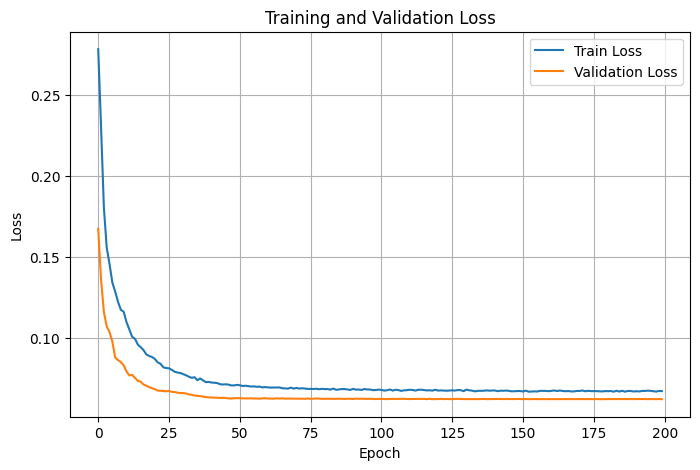

Embeddings shape: (6000, 3)


In [35]:
from common.losses import continuous_contrastive_loss, Q_distance
from functools import partial
from metric_learning.model import Embedder,TrainConfig, train_model, get_embeddings
from common.utils import plot_loss_curves

save_dir = Path('models')
save_dir.mkdir(exist_ok=True)

BATCH_SIZE = 128
NUM_EPOCHS = 200
LEARNING_RATE = 3e-4
EMBEDDING_SIZE = 3
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader, test_loader = make_balanced_train_test_dataset(
                                Configurations, X, 
                                batch_size=BATCH_SIZE, 
                                train_ratio=0.8, 
                            )
train = True
save_model = True
if train:
    model = Embedder(embedding_size=EMBEDDING_SIZE).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # warmup epochs
    warmup_epochs = max(1, int(0.05 * NUM_EPOCHS))
    sched1 = LinearLR(optimizer, start_factor=1e-2, end_factor=1.0, total_iters=warmup_epochs)
    sched2 = CosineAnnealingLR(optimizer, T_max=(NUM_EPOCHS - warmup_epochs))
    scheduler = SequentialLR(optimizer, schedulers=[sched1, sched2], milestones=[warmup_epochs])


    loss_function = partial(continuous_contrastive_loss,mu=1.0)

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_function=loss_function,
        Q_distance=partial(Q_distance, c_min = COS_MIN_GLOBAL, c_max = COS_MAX_GLOBAL),
        train_loader=train_loader,
        test_loader=test_loader,
    )

    avg_loss, avg_val_loss = train_model(config, num_epochs=NUM_EPOCHS)
    plot_loss_curves(avg_loss, avg_val_loss)

    if save_model:
        torch.save({
            'model_state_dict': model.state_dict(),
            'embedding_size': EMBEDDING_SIZE,
        }, save_dir / 'embedder.pt')
else:
    checkpoint = torch.load(save_dir / 'embedder.pt', map_location=device, weights_only=True)

    model = Embedder(embedding_size=checkpoint['embedding_size']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    config = TrainConfig(
        device=device,
        model=model,
        optimizer=None,
        scheduler=None,
        train_loader=None,
        test_loader=None,
    )

# Get embeddings for all configurations
all_embeddings = get_embeddings(config, Configurations)
print(f"Embeddings shape: {all_embeddings.shape}")


### Clustering of Monte Carlo embeddings

here, we shall cluster samples in the embedding space and compare to the original clustering.

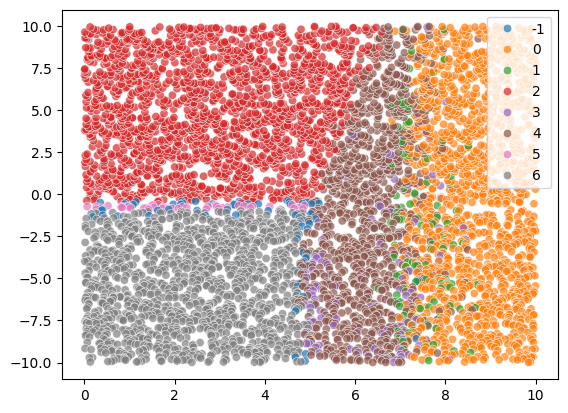

In [36]:
hd_contr = HDBSCAN(min_cluster_size=30, cluster_selection_epsilon=0.016, cluster_selection_method='eom').fit(all_embeddings)
Labels_contr = hd_contr.labels_

ax = sns.scatterplot(x=Values[:, 1], y=Values[:, 0], hue=Labels_contr, palette='tab10', alpha=0.7)

### Optimized configurations and clustering

In [37]:
data_grad = DataWithLabels.from_npz('data/optimized_configs.npz')
embeddings_grad = get_embeddings(config, data_grad.configurations)

<Axes: >

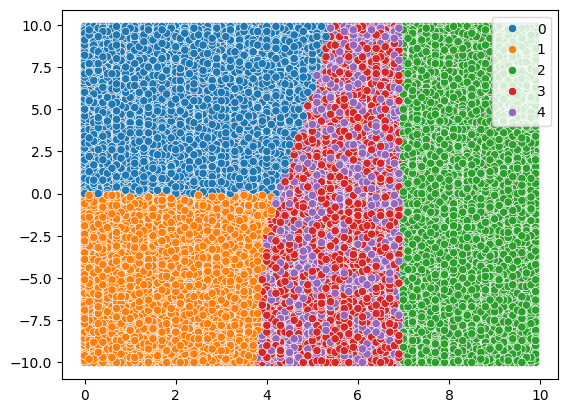

In [42]:
hd_grad = HDBSCAN(min_cluster_size=15, cluster_selection_epsilon=0.012, cluster_selection_method='eom').fit(embeddings_grad)
Labels_grad = hd_grad.labels_

Values_grad = data_grad.values
sns.scatterplot(x=Values_grad[:, 1], y=Values_grad[:, 0], hue=Labels_grad, palette='tab10')

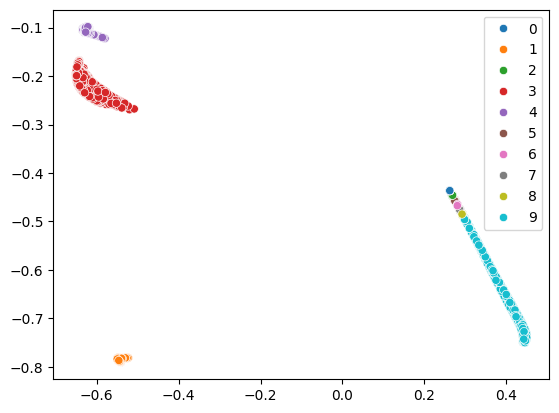

<Axes: >

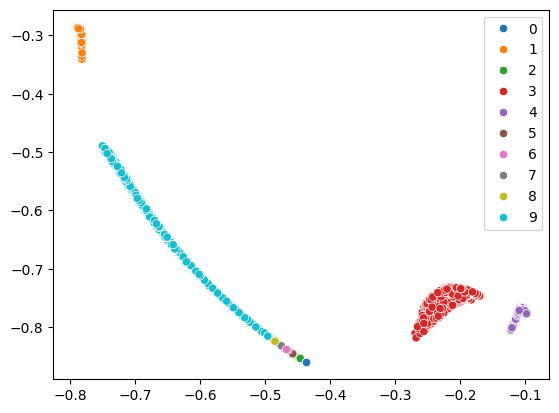

In [40]:
sns.scatterplot(x=embeddings_grad[:, 0], y=embeddings_grad[:, 1], hue=Labels_grad, palette='tab10')
plt.show()
sns.scatterplot(x=embeddings_grad[:, 1], y=embeddings_grad[:, 2], hue=Labels_grad, palette='tab10')